In [ ]:
# Import the libraries we need
import pandas as pd       # For working with data tables
import numpy as np        # For numbers and calculations
import sqlite3            # For our database
import warnings
warnings.filterwarnings('ignore')   # Hide ugly warning messages

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# Load the CSV file into a DataFrame
# A DataFrame is like an Excel spreadsheet inside Python
df = pd.read_csv('Superstore.csv', encoding='latin1')

# Show the first 5 rows to confirm it loaded
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# How many rows and columns?
print("Shape:", df.shape)

# What are the column names?
print("\nColumns:", df.columns.tolist())

# What types of data does each column have?
print("\nData Types:")
print(df.dtypes)

# Any missing values?
print("\nMissing values per column:")
print(df.isnull().sum())

# Quick statistical summary of numeric columns
# df.describe() → gives min, max, average, etc. for number columns
df.describe()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
# Make a copy so we don't ruin the original data
df_clean = df.copy()

# 1️⃣ Remove duplicate rows
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Removed {before - after} duplicate rows")

# 2️⃣ Convert date columns to proper date format
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'], errors='coerce')
df_clean['Ship Date'] = pd.to_datetime(df_clean['Ship Date'], errors='coerce')
print("✅ Dates converted")

# 3️⃣ Handle missing values
# For text columns: fill with 'Unknown'
# For number columns: fill with 0
text_cols = df_clean.select_dtypes(include='object').columns
num_cols = df_clean.select_dtypes(include=np.number).columns

df_clean[text_cols] = df_clean[text_cols].fillna('Unknown')
df_clean[num_cols] = df_clean[num_cols].fillna(0)
print("✅ Missing values handled")

# 4️⃣ Clean column names (remove spaces, make lowercase)
df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(' ', '_')
print("✅ Column names cleaned")

# 5️⃣ Remove rows with zero or negative sales (data errors)
df_clean = df_clean[df_clean['sales'] > 0]
print("✅ Invalid sales rows removed")

# 6️⃣ Add helpful new columns
df_clean['year'] = df_clean['order_date'].dt.year
df_clean['month'] = df_clean['order_date'].dt.month
df_clean['month_name'] = df_clean['order_date'].dt.month_name()
print("✅ Date columns added (year, month)")

# Show me the final cleaned data
print(f"\n🎉 Cleaning complete! Final shape: {df_clean.shape}")
df_clean.head()

Removed 0 duplicate rows
✅ Dates converted
✅ Missing values handled
✅ Column names cleaned
✅ Invalid sales rows removed
✅ Date columns added (year, month)

🎉 Cleaning complete! Final shape: (9994, 24)


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,category,sub-category,product_name,sales,quantity,discount,profit,year,month,month_name
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October


In [ ]:
# Create a connection to a SQLite database file
# If the file doesn't exist, SQLite creates it automatically
conn = sqlite3.connect('sales.db')

# Write our cleaned DataFrame to a table named 'sales'
df_clean.to_sql('sales', conn, if_exists='replace', index=False)

print("✅ Data successfully saved to SQLite database!")

# Quick check — let's count how many rows are in the database
result = pd.read_sql("SELECT COUNT(*) AS total_rows FROM sales", conn)
print(result)

✅ Data successfully saved to SQLite database!
   total_rows
0        9994


In [ ]:
# A helper function so we don't repeat ourselves
def run_query(sql):
    """Run any SQL query and return the result as a clean table"""
    return pd.read_sql(sql, conn)

print("✅ Helper function ready!")

✅ Helper function ready!


Query 1: Total Sales Overview

In [ ]:
query1 = """
SELECT
    COUNT(*) AS total_orders,
    SUM(sales) AS total_revenue,
    AVG(sales) AS average_order_value,
    SUM(profit) AS total_profit
FROM sales;
"""

run_query(query1)

,total_orders,total_revenue,average_order_value,total_profit
0,9994,2.297201e+06,229.858001,286397.0217


Query 2: Top 10 Selling Products

In [ ]:
query2 = """
SELECT
    product_name,
    SUM(quantity) AS units_sold,
    SUM(sales) AS revenue
FROM sales
GROUP BY product_name
ORDER BY revenue DESC
LIMIT 10;
"""

run_query(query2)

,product_name,units_sold,revenue
0,Canon imageCLASS 2200 Advanced Copier,20,61599.824
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,31,27453.384
2,Cisco TelePresence System EX90 Videoconferenci...,6,22638.480
3,HON 5400 Series Task Chairs for Big and Tall,39,21870.576
4,GBC DocuBind TL300 Electric Binding System,37,19823.479
5,GBC Ibimaster 500 Manual ProClick Binding System,48,19024.500
6,Hewlett Packard LaserJet 3310 Copier,38,18839.686
7,HP Designjet T520 Inkjet Large Format Printer ...,12,18374.895
8,GBC DocuBind P400 Electric Binding System,27,17965.068
9,High Speed Automatic Electric Letter Opener,11,17030.312


Query 3: Revenue by Category

*Tells which product categories are top performers.Sometimes a category has high revenue but low profit. That's a red flag *

In [ ]:
query3 = """
SELECT
    category,
    SUM(sales) AS revenue,
    SUM(profit) AS profit,
    COUNT(*) AS orders
FROM sales
GROUP BY category
ORDER BY revenue DESC;
"""

run_query(query3)

,category,revenue,profit,orders
0,Technology,836154.0330,145454.9481,1847
1,Furniture,741999.7953,18451.2728,2121
2,Office Supplies,719047.0320,122490.8008,6026


Query 4: Monthly Sales Trend


What this tells you: How sales change month-by-month. Are there seasonal patterns?
Business value: Helps with forecasting, staffing, and inventory planning.

In [ ]:
query4 = """
SELECT
    year,
    month,
    SUM(sales) AS monthly_revenue,
    COUNT(*) AS orders
FROM sales
GROUP BY year, month
ORDER BY year, month;
"""

run_query(query4)

,year,month,monthly_revenue,orders
0,2014,1,14236.8950,79
1,2014,2,4519.8920,46
2,2014,3,55691.0090,157
3,2014,4,28295.3450,135
4,2014,5,23648.2870,122
5,2014,6,34595.1276,135
6,2014,7,33946.3930,143
7,2014,8,27909.4685,153
8,2014,9,81777.3508,268
9,2014,10,31453.3930,159


Query 5: Top 10 Customers by Revenue

What this tells you: Your VIP customers.
Business value: These are the customers you give loyalty perks, special offers, or personalized outreach.

In [ ]:
query5 = """
SELECT
    customer_name,
    COUNT(*) AS orders_placed,
    SUM(sales) AS total_spent
FROM sales
GROUP BY customer_name
ORDER BY total_spent DESC
LIMIT 10;
"""

run_query(query5)

,customer_name,orders_placed,total_spent
0,Sean Miller,15,25043.050
1,Tamara Chand,12,19052.218
2,Raymond Buch,18,15117.339
3,Tom Ashbrook,10,14595.620
4,Adrian Barton,20,14473.571
5,Ken Lonsdale,29,14175.229
6,Sanjit Chand,22,14142.334
7,Hunter Lopez,11,12873.298
8,Sanjit Engle,19,12209.438
9,Christopher Conant,11,12129.072


Query 6: Best Performing Region

What this tells you: Which region brings in the most business. Useful for expansion decisions.

In [ ]:
query6 = """
SELECT
    region,
    SUM(sales) AS revenue,
    SUM(profit) AS profit,
    COUNT(DISTINCT customer_name) AS unique_customers
FROM sales
GROUP BY region
ORDER BY revenue DESC;
"""

run_query(query6)

,region,revenue,profit,unique_customers
0,West,725457.8245,108418.4489,686
1,East,678781.2400,91522.7800,674
2,Central,501239.8908,39706.3625,629
3,South,391721.9050,46749.4303,512


In [ ]:
# Save each query result into a variable
overview      = run_query(query1)
top_products  = run_query(query2)
by_category   = run_query(query3)
monthly_trend = run_query(query4)
top_customers = run_query(query5)
by_region     = run_query(query6)

print("✅ All 6 analysis results saved!")
print("\nQuick preview of each:")
print("\n📊 OVERVIEW:")
print(overview)
print("\n🏆 TOP 5 PRODUCTS:")
print(top_products.head())
print("\n📦 BY CATEGORY:")
print(by_category)

✅ All 6 analysis results saved!

Quick preview of each:

📊 OVERVIEW:
   total_orders  total_revenue  average_order_value  total_profit
0          9994   2.297201e+06           229.858001   286397.0217

🏆 TOP 5 PRODUCTS:
                                        product_name  units_sold    revenue
0              Canon imageCLASS 2200 Advanced Copier          20  61599.824
1  Fellowes PB500 Electric Punch Plastic Comb Bin...          31  27453.384
2  Cisco TelePresence System EX90 Videoconferenci...           6  22638.480
3       HON 5400 Series Task Chairs for Big and Tall          39  21870.576
4         GBC DocuBind TL300 Electric Binding System          37  19823.479

📦 BY CATEGORY:
          category      revenue       profit  orders
0       Technology  836154.0330  145454.9481    1847
1        Furniture  741999.7953   18451.2728    2121
2  Office Supplies  719047.0320  122490.8008    6026


 find products that sell a lot but lose money

In [ ]:
query_losers = """
SELECT
    product_name,
    SUM(quantity) AS units_sold,
    SUM(sales) AS revenue,
    SUM(profit) AS profit
FROM sales
GROUP BY product_name
HAVING SUM(profit) < 0
ORDER BY profit ASC
LIMIT 10;
"""

losing_products = run_query(query_losers)
print("⚠️ Top 10 Profit-Losing Products:")
losing_products

⚠️ Top 10 Profit-Losing Products:


,product_name,units_sold,revenue,profit
0,Cubify CubeX 3D Printer Double Head Print,9,11099.963,-8879.9704
1,Lexmark MX611dhe Monochrome Laser Printer,18,16829.901,-4589.9730
2,Cubify CubeX 3D Printer Triple Head Print,4,7999.980,-3839.9904
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,27,9917.640,-2876.1156
4,Bush Advantage Collection Racetrack Conference...,33,9544.725,-1934.3976
5,GBC DocuBind P400 Electric Binding System,27,17965.068,-1878.1662
6,Cisco TelePresence System EX90 Videoconferenci...,6,22638.480,-1811.0784
7,Martin Yale Chadless Opener Electric Letter Op...,22,16656.200,-1299.1836
8,Balt Solid Wood Round Tables,19,6518.754,-1201.0581
9,BoxOffice By Design Rectangular and Half-Moon ...,15,1706.250,-1148.4375


It groups orders by discount level (0%, 1-20%, 21-50%, over 50%) and shows how profit changes for each group.
What you'll likely see:

0% discount → High profit ✅
1-20% discount → Still profitable ✅
21-50% discount → Lower profit ⚠️
Over 50% discount → NEGATIVE profit ❌

This is a stunning finding. It proves the business is losing money whenever it discounts above 50%.

In [ ]:
query_discount_impact = """
SELECT
    CASE
        WHEN discount = 0 THEN '0% Discount'
        WHEN discount <= 0.2 THEN '1-20% Discount'
        WHEN discount <= 0.5 THEN '21-50% Discount'
        ELSE 'Over 50% Discount'
    END AS discount_range,
    COUNT(*) AS orders,
    ROUND(SUM(sales), 2) AS revenue,
    ROUND(SUM(profit), 2) AS profit,
    ROUND(AVG(profit), 2) AS avg_profit_per_order
FROM sales
GROUP BY discount_range
ORDER BY profit DESC;
"""

discount_analysis = run_query(query_discount_impact)
print("💡 Discount vs Profit Analysis:")
discount_analysis

💡 Discount vs Profit Analysis:


,discount_range,orders,revenue,profit,avg_profit_per_order
0,0% Discount,4798,1087908.47,320987.60,66.90
1,1-20% Discount,3803,846522.24,100785.47,26.50
2,21-50% Discount,537,298541.41,-58817.00,-109.53
3,Over 50% Discount,856,64228.74,-76559.05,-89.44


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look nice
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("✅ Chart setup ready!")

✅ Chart setup ready!


**Chart 1: Top 10 Products by Revenue 🏆**

plt.barh(...) → horizontal bar chart (easier to read long product names)
plt.gca().invert_yaxis() → puts the highest at the top (visual hierarchy)
plt.savefig(...) → saves the chart as an image file (for your GitHub + report)

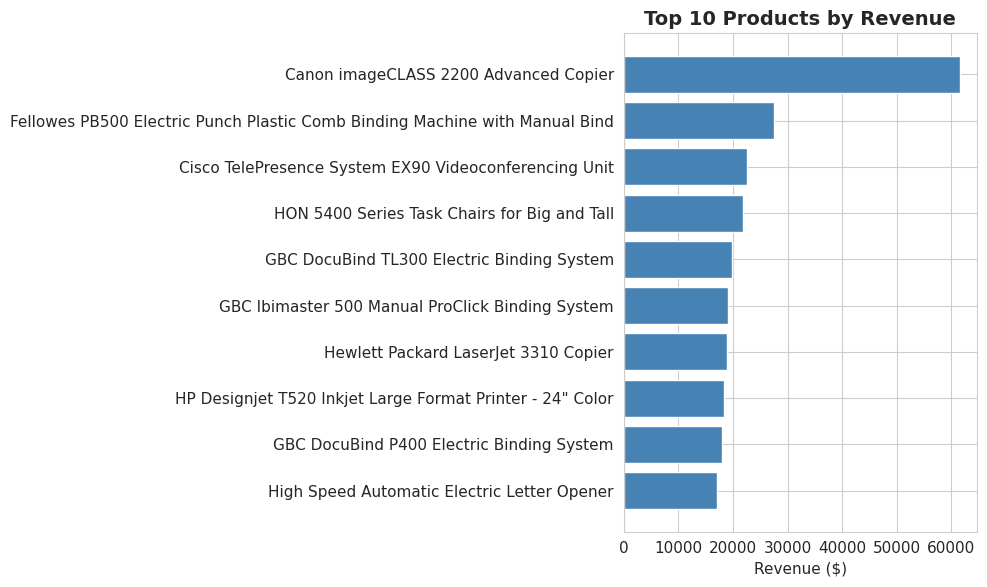

✅ Saved as chart_top_products.png


In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(top_products['product_name'], top_products['revenue'], color='steelblue')
plt.xlabel('Revenue ($)')
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()   # Highest on top
plt.tight_layout()
plt.savefig('chart_top_products.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as chart_top_products.png")


**Chart 2: Revenue by Category 📦**

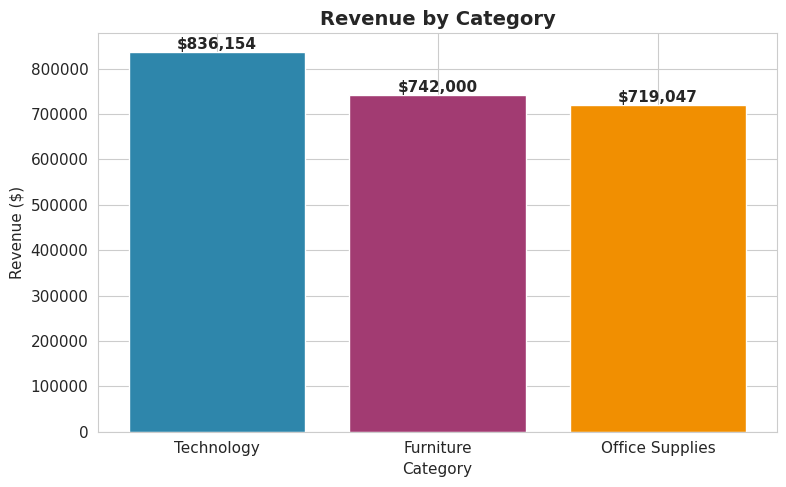

✅ Saved as chart_categories.png


In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(by_category['category'], by_category['revenue'], color=['#2E86AB', '#A23B72', '#F18F01'])
plt.title('Revenue by Category', fontsize=14, fontweight='bold')
plt.ylabel('Revenue ($)')
plt.xlabel('Category')
for i, v in enumerate(by_category['revenue']):
    plt.text(i, v, f'${v:,.0f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('chart_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as chart_categories.png")

# Chart 3: Monthly Sales Trend 📈

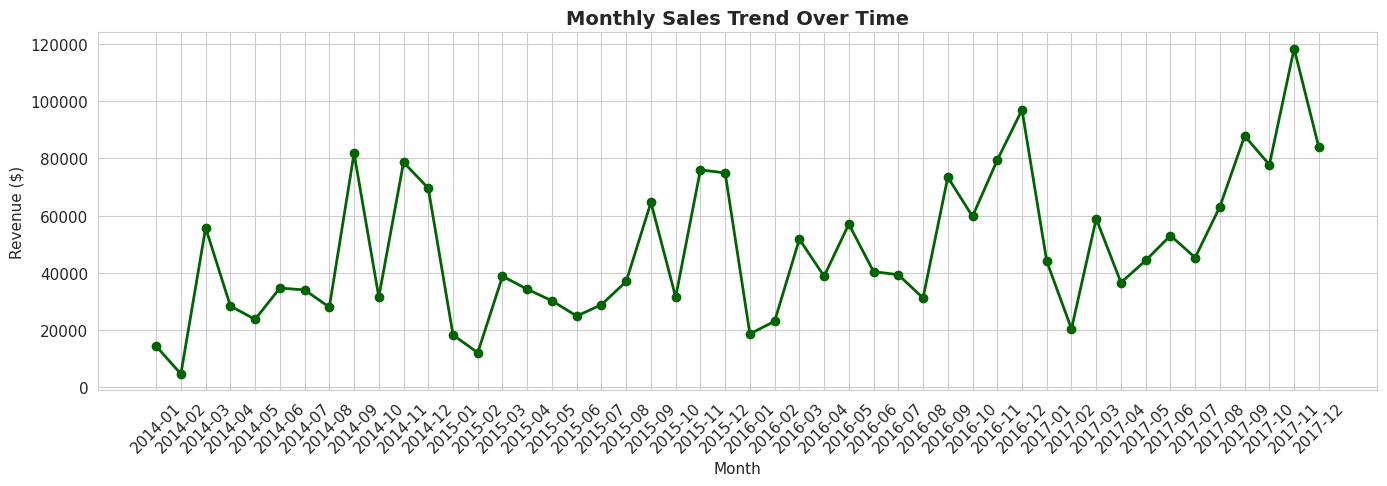

✅ Saved as chart_monthly_trend.png


In [ ]:
# Create a combined "year-month" label for x-axis
monthly_trend['period'] = monthly_trend['year'].astype(str) + '-' + monthly_trend['month'].astype(str).str.zfill(2)

plt.figure(figsize=(14, 5))
plt.plot(monthly_trend['period'], monthly_trend['monthly_revenue'], marker='o', linewidth=2, color='darkgreen')
plt.title('Monthly Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as chart_monthly_trend.png")

# Chart 4: Discount Impact on Profit 💸

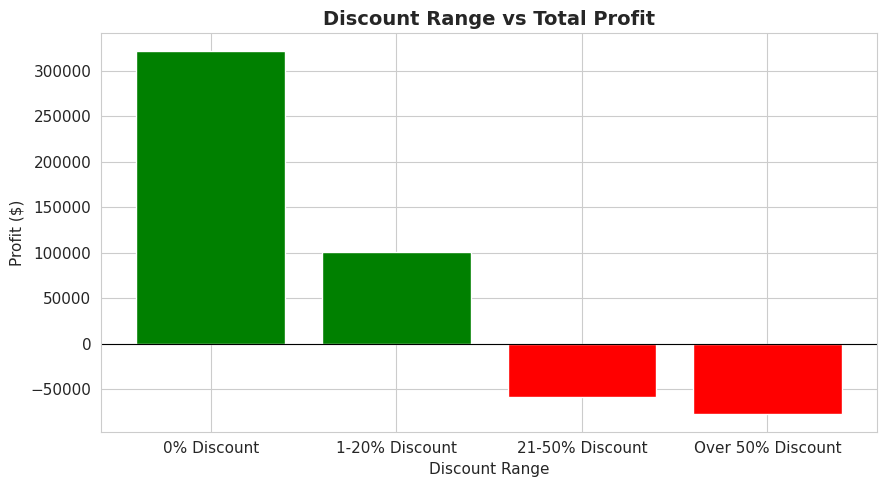

✅ Saved as chart_discount_impact.png


In [ ]:
plt.figure(figsize=(9, 5))
colors = ['green' if x >= 0 else 'red' for x in discount_analysis['profit']]
plt.bar(discount_analysis['discount_range'], discount_analysis['profit'], color=colors)
plt.title('Discount Range vs Total Profit', fontsize=14, fontweight='bold')
plt.ylabel('Profit ($)')
plt.xlabel('Discount Range')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('chart_discount_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved as chart_discount_impact.png")

In [ ]:
# Create an Excel file with multiple tabs — one for each insight
with pd.ExcelWriter('Business_Report.xlsx', engine='openpyxl') as writer:
    overview.to_excel(writer, sheet_name='Overview', index=False)
    top_products.to_excel(writer, sheet_name='Top Products', index=False)
    by_category.to_excel(writer, sheet_name='By Category', index=False)
    monthly_trend.to_excel(writer, sheet_name='Monthly Trend', index=False)
    top_customers.to_excel(writer, sheet_name='Top Customers', index=False)
    by_region.to_excel(writer, sheet_name='By Region', index=False)
    discount_analysis.to_excel(writer, sheet_name='Discount Impact', index=False)
    losing_products.to_excel(writer, sheet_name='Loss Makers', index=False)

print("✅ Business_Report.xlsx created successfully!")
print("📂 Check the left file panel — you can download it from there.")

✅ Business_Report.xlsx created successfully!
📂 Check the left file panel — you can download it from there.


In [25]:
# Connect Colab to your Google account
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

print("✅ Connected to Google Sheets!")

✅ Connected to Google Sheets!


What happens when you run this:

A popup will appear asking you to sign in to your Google account
Sign in with your personal Gmail (the one connected to Colab)
Click "Allow"
Done!

**What this does: Creates a brand-new Google Sheet in your Google Drive named Sales_Analysis_Report_Aisha. The link in the output will open it directly.**

In [26]:
# Create a fresh Google Sheet
spreadsheet = gc.create('Sales_Analysis_Report_Aisha')

# Get the link to share it
print(f"✅ Google Sheet created!")
print(f"🔗 Open it here: https://docs.google.com/spreadsheets/d/{spreadsheet.id}")

✅ Google Sheet created!
🔗 Open it here: https://docs.google.com/spreadsheets/d/17LbTu47T8HTTCjWocIH64anQKFQTn0xu0byv89k-oJQ


In [27]:
# Helper function to upload a DataFrame to Google Sheets
def upload_to_sheet(df, sheet_name):
    try:
        worksheet = spreadsheet.add_worksheet(title=sheet_name, rows=1000, cols=20)
    except:
        worksheet = spreadsheet.worksheet(sheet_name)

    # Convert DataFrame to list of lists (Google Sheets format)
    data = [df.columns.tolist()] + df.astype(str).values.tolist()
    worksheet.update('A1', data)
    print(f"  ✅ Uploaded: {sheet_name}")

# Upload all our analysis tables
print("📤 Uploading data to Google Sheets...\n")
upload_to_sheet(overview, 'Overview')
upload_to_sheet(top_products, 'Top Products')
upload_to_sheet(by_category, 'By Category')
upload_to_sheet(monthly_trend, 'Monthly Trend')
upload_to_sheet(top_customers, 'Top Customers')
upload_to_sheet(by_region, 'By Region')
upload_to_sheet(discount_analysis, 'Discount Impact')
upload_to_sheet(losing_products, 'Loss Makers')

# Remove the default empty sheet
try:
    spreadsheet.del_worksheet(spreadsheet.worksheet('Sheet1'))
except:
    pass

print(f"\n🎉 ALL DONE! Open your Google Sheet:")
print(f"🔗 https://docs.google.com/spreadsheets/d/{spreadsheet.id}")

📤 Uploading data to Google Sheets...

  ✅ Uploaded: Overview
  ✅ Uploaded: Top Products
  ✅ Uploaded: By Category
  ✅ Uploaded: Monthly Trend
  ✅ Uploaded: Top Customers
  ✅ Uploaded: By Region
  ✅ Uploaded: Discount Impact
  ✅ Uploaded: Loss Makers

🎉 ALL DONE! Open your Google Sheet:
🔗 https://docs.google.com/spreadsheets/d/17LbTu47T8HTTCjWocIH64anQKFQTn0xu0byv89k-oJQ
